In [36]:
# Get daily constraint ranked by the abs RT - DA 
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')

import pandas as pd
from nighthawk.data import Constraint

In [37]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-05-28


In [38]:
def get_recent_constraint_mvalue(start_dt=(pd.Timestamp(pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')) - pd.Timedelta(days=3)).strftime('%Y-%m-%d'), \
                                 end_dt=pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d'), \
                                    threshold=1000):

    opex = 'SPP'
    end_dt = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(end_dt) - pd.Timedelta(days=3)).strftime('%Y-%m-%d')


    print(f"start_dt: {start_dt}, end_dt: {end_dt}, Market: {opex}")

    # Get RT and DA hourly mvalues for all constraints over the date range
    print("Fetching RT mvalues...")
    mv_rt = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='RT', granularity='hourly')

    print("Fetching DA mvalues...")
    mv_da = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='DA', granularity='hourly')

    print(f"RT constraints: {mv_rt['oops_constraint_num'].nunique()}, DA constraints: {mv_da['oops_constraint_num'].nunique()}")

    # Sum mvalues per constraint
    rt_total = mv_rt.groupby('oops_constraint_num')['mvalue'].sum().rename('rt_total')
    da_total = mv_da.groupby('oops_constraint_num')['mvalue'].sum().rename('da_total')

    # Merge and compute abs(RT - DA), ranked descending
    merged = pd.merge(rt_total, da_total, on='oops_constraint_num', how='outer').fillna(0)
    merged['rt_da'] = (merged['rt_total'] - merged['da_total'])
    merged['abs_rt_da_diff'] = (merged['rt_total'] - merged['da_total']).abs()
    merged = merged.sort_values('abs_rt_da_diff', ascending=False).reset_index()

    # Get constraint details
    all_cons = merged[['oops_constraint_num']].copy()
    print("Fetching constraint details...")
    details_rt = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='RT')
    details_da = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='DA')
    details = pd.concat([details_rt, details_da]).drop_duplicates('oops_constraint_num')

    # Merge everything
    result = pd.merge(merged, details[['oops_constraint_num', 'monitored_clean', 'contingency_clean']], on='oops_constraint_num', how='left')
    result = result.rename(columns={'monitored_clean': 'monitored', 'contingency_clean': 'contingency'})
    result_final = result.groupby('monitored')[['rt_total','da_total','rt_da']].sum().reset_index()
    result_final['abs_rt_da_diff'] = abs(result_final['rt_da'])
    result_final = result_final[result_final['abs_rt_da_diff']>threshold]
    result = result[result['monitored'].isin(result_final.monitored.tolist())]


    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.max_colwidth', 80)
    display(result[['oops_constraint_num', 'rt_total', 'da_total', 'rt_da', 'abs_rt_da_diff', 'monitored', 'contingency']])

    return result 

In [39]:
def get_node_dfax_from_constraint_num(result):
    opex= 'SPP'
    con_df = result[['oops_constraint_num']].drop_duplicates()

    dfax = Constraint(oops_constraint_num_df=con_df, market=opex).get_dfax_on_all_nodes(dfax_cutoff=0.05, dfax_type='RT')

    node_dfax = (result
        .merge(dfax, on='oops_constraint_num')
        .sort_values(['abs_rt_da_diff', 'dfax'], ascending=[False, False])
    )

    columns = ['oops_constraint_num','node_num','dfax']
    node_dfax = node_dfax[columns]
    return node_dfax

In [40]:
def get_hourly_mvalue_for_constraint_num(result, weeks=104):

    opex='SPP'
    end_dt2   = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    start_dt2 = (pd.Timestamp(end_dt2) - pd.Timedelta(weeks=weeks)).strftime('%Y-%m-%d')

    con_df = result[['oops_constraint_num']].drop_duplicates()

    # Step 1: daily mvalues to find active days
    mv_rt_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='RT', granularity='daily')
    mv_da_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='DA', granularity='daily')

    # Step 2: keep only days where mvalue != 0
    rt_active = mv_rt_daily[mv_rt_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()
    da_active = mv_da_daily[mv_da_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()

    print(f"RT active constraint-days: {len(rt_active)}")
    print(f"DA active constraint-days: {len(da_active)}")

    # Step 3: fetch hourly mvalues only for those active days
    def get_hourly_for_active_days(active_df, ctype):
        if active_df.empty:
            return pd.DataFrame()
        results = []
        for con_num, grp in active_df.groupby('oops_constraint_num'):
            dates = grp['dt'].astype(str).tolist()
            mv_h = Constraint(
                oops_constraint_num_df=pd.DataFrame({'oops_constraint_num': [con_num]}),
                market=opex
            ).get_mvalues(start_dt=min(dates), end_dt=max(dates), type=ctype, granularity='hourly')
            mv_h = mv_h[mv_h['dt'].astype(str).isin(dates)]
            results.append(mv_h)
        return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

    mv_rt_2w = get_hourly_for_active_days(rt_active, 'RT')
    mv_da_2w = get_hourly_for_active_days(da_active, 'DA')

    # Step 3: outer join on constraint, dt, hr — compute rt - da per hour
    mv_merged = (
        mv_rt_2w.rename(columns={'mvalue': 'rt_mvalue'})
        .merge(mv_da_2w.rename(columns={'mvalue': 'da_mvalue'}),
            on=['oops_constraint_num', 'dt', 'hr'], how='outer')
        .fillna(0)
    )
    mv_merged['rt_da'] = mv_merged['rt_mvalue'] - mv_merged['da_mvalue']
    print(mv_merged.head())

    names = result[['oops_constraint_num', 'monitored', 'contingency']].drop_duplicates()
    mv_merged = (mv_merged
        .merge(names, on='oops_constraint_num', how='left')
        .sort_values(['oops_constraint_num', 'dt', 'hr'])
        .reset_index(drop=True)
    )
    mv_merged['dt'] = pd.to_datetime(mv_merged['dt']).dt.strftime('%Y-%m-%d')
    print(f"\nMerged hourly rows: {len(mv_merged)}")
    display(mv_merged)
    return mv_merged

In [125]:
from nighthawk.data.network.node import Node

def get_constraint_node_prices_from_constraint_num(mv_merged, node_dfax, monitored_name):
    con_list = mv_merged.loc[mv_merged['monitored'] == monitored_name, 'oops_constraint_num'].unique().tolist()
    not_found= []
    if not con_list:
        print(f"No constraints found for monitored name: '{monitored_name}'")
        return pd.DataFrame()

    results = []
    for con_num in con_list:
        node_map = node_dfax[node_dfax['oops_constraint_num'] == con_num][['node_num', 'dfax']].drop_duplicates()
        mv_con   = mv_merged[mv_merged['oops_constraint_num'] == con_num].copy()

        if node_map.empty or mv_con.empty:
            continue

        mv_con['oops_constraint_num'] = con_num
        mv_con['monitored']   = monitored_name
        mv_con['contingency'] = mv_merged.loc[mv_merged['oops_constraint_num'] == con_num, 'contingency'].iloc[0]

        mv_nodes  = mv_con.merge(node_map, how='cross')
        node_list = node_map['node_num'].astype(int).tolist()

        prices_list = []
        for dt in mv_con.dt.unique():
            p = Node(node_nums=node_list, market='SPP').get_price(
                start_dt=dt, end_dt=dt,
                component=['LMP'], type=['DA', 'RT'], granularity='hourly'
            )[['dt', 'hr', 'node_num', 'da_total', 'rt_total']].rename(
                columns={'da_total': 'node_da_lmp', 'rt_total': 'node_rt_lmp'}
            )
            prices_list.append(p)

        prices = pd.concat(prices_list, ignore_index=True)
        results.append(mv_nodes.merge(prices, on=['dt', 'hr', 'node_num'], how='left'))
    if not results:
        not_found.append(monitored_name) 
        print(monitored_name, 'could not find the dfax value')
        return pd.DataFrame()
    else: 
        result = pd.concat(results, ignore_index=True).sort_values(['dt', 'hr', 'node_num']).reset_index(drop=True)
    return result, 


def get_constraints_node_price(mvalue, nodedfax, listofnames=[]):
    
    if not listofnames:
        # default to be the all monitored names
        all_monitored = mvalue['monitored'].unique().tolist()
    else: all_monitored = listofnames

    mv_final = pd.concat([get_constraint_node_prices_from_constraint_num(mv_merged, nodedfax, name) \
                          for name in all_monitored],ignore_index=True)
        
    mv_grouped = (mv_final
    .groupby(['monitored', 'dt', 'hr', 'node_num'], as_index=False)
    .agg(rt_mvalue=('rt_mvalue', 'sum'),
         da_mvalue=('da_mvalue', 'sum'),
         rt_da=('rt_da', 'sum'),
         dfax=('dfax', 'first'),
         node_da_lmp=('node_da_lmp', 'first'),
         node_rt_lmp=('node_rt_lmp', 'first')))
    
    print(f"\nTotal rows: {len(mv_final)}")
    display(mv_grouped[[ 'monitored', 'dt', 'hr',
                    'node_num', 'dfax', 'rt_mvalue', 'da_mvalue', 'rt_da',
                    'node_da_lmp', 'node_rt_lmp']])
    
    return mv_grouped



In [110]:
import numpy as np
def get_metrics_for_nodes(mv_grouped):
    mv_grouped['node_rt_da']          = mv_grouped['node_rt_lmp'] - mv_grouped['node_da_lmp']
    mv_grouped['predicted_node_rt_da'] = -mv_grouped['dfax'] * mv_grouped['rt_da']

    # only evaluate hours where the constraint is actually binding
    active = mv_grouped[mv_grouped['rt_da'] != 0].copy()

    def node_constraint_stats(grp):
        x = grp['predicted_node_rt_da']
        y = grp['node_rt_da']
        dfx= grp['dfax'].iloc[0]
        mask = x.notna() & y.notna()
        x, y = x[mask], y[mask]
        n = len(x)
        if n < 3:
            return pd.Series({'dfax': dfx, 'corr': np.nan, 'sign_acc': np.nan,
                            'mean_pred': np.nan, 'mean_actual': np.nan, 'n': n})

        corr     = x.corr(y)
        sign_acc = (np.sign(x) == np.sign(y)).mean()
        return pd.Series({'dfax':dfx, 'corr': corr, 'sign_acc': sign_acc,
                        'mean_pred': x.mean(), 'mean_actual': y.mean(), 'n': n})

    stats_df = (active
        .groupby(['monitored', 'node_num'])
        .apply(node_constraint_stats)
        .reset_index()
        .sort_values(['monitored', 'corr'], ascending=[True, False])
        .reset_index(drop=True)
    )

    for monitored, grp in stats_df.groupby('monitored', sort=True):
        print(f"\n{'='*60}")
        print(f"  {monitored}")
        print(f"{'='*60}")
        display(grp.drop(columns='monitored').reset_index(drop=True))


In [52]:
mvalue= get_recent_constraint_mvalue()
dfax= get_node_dfax_from_constraint_num(mvalue)
hourly_mvalue = get_hourly_mvalue_for_constraint_num(mvalue)

start_dt: 2026-05-23, end_dt: 2026-05-26, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 43, DA constraints: 112
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,683261,-11145.7973,0.0000,-11145.7973,11145.7973,lnpayne_wf-paoli2,wfec:anadarkofletch3comanch2:138
1,666103,-10843.9474,0.0000,-10843.9474,10843.9474,lnjarb-166thstr,wr:87th_ststra:345:1:9
2,686327,0.0000,-3989.7167,3989.7167,3989.7167,lnpayne_wf-paoli2,wfec:anadarkofletch3comanch2:138
3,498649,-3878.0871,0.0000,-3878.0871,3878.0871,lngord-maiz,wr:wichbent:345:1:8
4,798013,-3690.7977,0.0000,-3690.7977,3690.7977,lnfremont-sub976,mecoppd:raunft_cal:345:2:10
5,875888,-2562.9422,0.0000,-2562.9422,2562.9422,lnalcova-miraclem,wacm:miraclemalcova:115:1:5
6,545011,0.0000,-2372.5284,2372.5284,2372.5284,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
7,533429,0.0000,-1616.0213,1616.0213,1616.0213,ln70_bluf-sub1214,lesoppd:wagenersub3454:345:1:11
8,509581,0.0000,-1500.8400,1500.8400,1500.8400,lngord-maiz,wr:wichbent:345:1:8
10,842371,0.0000,-1345.0276,1345.0276,1345.0276,lnfirstcrk-roanrdge,kcpl:nashuashale:345:1:11


RT active constraint-days: 405
DA active constraint-days: 481
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue     rt_da
0               498649  2024-06-20  15   -30.6441     0.0000  -30.6441
1               498649  2024-06-20  16   -77.1086     0.0000  -77.1086
2               498649  2024-06-20  17  -234.2100     0.0000 -234.2100
3               498649  2024-06-20  18  -348.7760     0.0000 -348.7760
4               498649  2024-06-20  19  -361.2762     0.0000 -361.2762

Merged hourly rows: 5936


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,498649,2024-06-20,15,-30.6441,0.0000,-30.6441,lngord-maiz,wr:wichbent:345:1:8
1,498649,2024-06-20,16,-77.1086,0.0000,-77.1086,lngord-maiz,wr:wichbent:345:1:8
2,498649,2024-06-20,17,-234.2100,0.0000,-234.2100,lngord-maiz,wr:wichbent:345:1:8
3,498649,2024-06-20,18,-348.7760,0.0000,-348.7760,lngord-maiz,wr:wichbent:345:1:8
4,498649,2024-06-20,19,-361.2762,0.0000,-361.2762,lngord-maiz,wr:wichbent:345:1:8
...,...,...,...,...,...,...,...,...
5931,875888,2026-04-30,21,-703.5877,0.0000,-703.5877,lnalcova-miraclem,wacm:miraclemalcova:115:1:5
5932,875888,2026-04-30,22,-124.7626,0.0000,-124.7626,lnalcova-miraclem,wacm:miraclemalcova:115:1:5
5933,875888,2026-05-24,19,-499.0048,0.0000,-499.0048,lnalcova-miraclem,wacm:miraclemalcova:115:1:5
5934,875888,2026-05-24,20,-1348.0807,0.0000,-1348.0807,lnalcova-miraclem,wacm:miraclemalcova:115:1:5


In [113]:
from nighthawk.data.pipeline.common_functions.wind import Wind
from nighthawk.data.pipeline.common_functions.load import Load

def get_weather_date(mv_merged):
    start_dt_f = mv_merged['dt'].min()
    end_dt_f   = mv_merged['dt'].max()

    rz_wind_df = Wind('SPP').get_res_zonal_wind(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)
    rz_load_df = Load('SPP').get_res_zonal_load(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)

    rz_wind_f_cols = [c for c in rz_wind_df.columns if 'forecast' in c]
    rz_load_f_cols = [c for c in rz_load_df.columns if 'forecast' in c]

    for df in [rz_wind_df, rz_load_df]:
        df['dt'] = df['dt'].astype(str)
        df['hr'] = df['hr'].astype(int)

    fundamentals = (rz_wind_df[['dt', 'hr'] + rz_wind_f_cols]
        .merge(rz_load_df[['dt', 'hr'] + rz_load_f_cols], on=['dt', 'hr'], how='outer'))

    available_zones = sorted(set(int(c.split('_')[0][2:]) for c in rz_wind_f_cols))
    print(f"Reserve zones available: {available_zones}")
    print(f"Wind cols: {rz_wind_f_cols}")
    print(f"Load cols: {rz_load_f_cols}")
    return fundamentals

In [116]:
def analyze_constraint_by_zone(fundamentals,mv_merged, monitored_name, reserve_zone, top):
    """
    Conditional binding-probability analysis for one constraint vs a reserve zone's forecasts.

    Parameters
    ----------
    monitored_name : str  – value from mv_merged['monitored'], e.g. 'lnrussett-sbrown'
    reserve_zone   : int  – SPP reserve zone number (1, 2, 3, 4, 5, or 21)

    Returns
    -------
    pd.DataFrame  – one row per forecast column with baseline/conditional prob and lift
    """
    grp = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return None

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['dt'] = binding_hours['dt'].astype(str)
    binding_hours['hr'] = binding_hours['hr'].astype(int)
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates
        for h in range(1, 25)
    ])

    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{reserve_zone}_') and 'forecast' in c]
    if not rz_cols:
        print(f"No forecast columns found for reserve zone {reserve_zone}.")
        print(f"Available rz columns: {[c for c in tmp.columns if c.startswith('rz')]}")
        return None

    baseline = tmp['binding'].mean()
    n_total  = len(tmp)

    rows = []
    for col in rz_cols:
        valid = tmp[[col, 'binding']].dropna()
        if len(valid) < 20:
            continue
        threshold = valid[col].quantile(top/100)
        above = valid[valid[col] > threshold]
        if len(above) < 5:
            continue
        cond_prob = above['binding'].mean()
        rows.append({
            'monitored':          monitored_name,
            'reserve_zone':       reserve_zone,
            'fundamental':        col,
            'baseline_prob':      round(baseline, 4),
            f'cond_prob_top{top}pct': round(cond_prob, 4),
            'lift_pct':           round(cond_prob / baseline - 1, 2) if baseline > 0 else None
        })

    result_df = pd.DataFrame(rows)
    print(f"Constraint  : '{monitored_name}'")
    print(f"Reserve zone: {reserve_zone}  |  Columns: {rz_cols}")
    print(f"Baseline binding rate: {baseline:.4f}  |  Total hours: {n_total}")
    display(result_df.sort_values('lift_pct', ascending=False))


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_constraint_seasonality(mv_merged, monitored_name):
    con_nums = mvalue.loc[mvalue['monitored'] == monitored_name, 'oops_constraint_num'].tolist()
    if not con_nums:
        print(f"No constraint found for '{monitored_name}'")
        return

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_colors = {
        'Dec': '#5b9bd5', 'Jan': '#5b9bd5', 'Feb': '#5b9bd5',
        'Mar': '#70ad47', 'Apr': '#70ad47', 'May': '#70ad47',
        'Jun': '#d62728', 'Jul': '#d62728', 'Aug': '#d62728',
        'Sep': '#ed7d31', 'Oct': '#ed7d31', 'Nov': '#ed7d31',
    }
    season_map = {
        'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
        'Sep': 'Fall',   'Oct': 'Fall',   'Nov': 'Fall',
        'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
        'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    }

    def build_monthly(df_daily):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']         = pd.to_datetime(d['dt'])
        d['month']      = d['dt'].dt.month
        d['month_name'] = d['dt'].dt.strftime('%b')
        s   = d.groupby(['dt', 'month', 'month_name'])['mvalue'].sum().reset_index()
        return (pd.DataFrame({'month': range(1, 13), 'month_name': month_labels})
                .merge(s, on=['month', 'month_name'], how='left').fillna(0))

    def build_yearly(df_daily):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']   = pd.to_datetime(d['dt'])
        d['year'] = d['dt'].dt.year
        s   = d.groupby(['dt', 'year'])['mvalue'].sum().reset_index()
        avg = s.groupby('year')['mvalue'].mean().reset_index()
        return avg

    rt_monthly = build_monthly(mv_rt_daily)
    da_monthly = build_monthly(mv_da_daily)
    rt_yearly  = build_yearly(mv_rt_daily)
    da_yearly  = build_yearly(mv_da_daily)

    # dominant season and month (based on RT abs mvalue)
    rt_monthly['abs_mv'] = rt_monthly['mvalue'].abs()
    rt_monthly['season'] = rt_monthly['month_name'].map(season_map)
    season_totals   = rt_monthly.groupby('season')['abs_mv'].sum()
    dominant_season = season_totals.idxmax()
    peak_month_row  = rt_monthly.loc[rt_monthly['abs_mv'].idxmax()]

    # hourly averages
    hourly   = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    rt_by_hr = (hourly.groupby('hr')['rt_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    da_by_hr = (hourly.groupby('hr')['da_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    rt_hr_colors = ['#aec7e8' if h <= 8 else '#ff7f0e' for h in rt_by_hr['hr']]
    da_hr_colors = ['#c5e0b4' if h <= 8 else '#9b59b6' for h in da_by_hr['hr']]

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    fig.suptitle(
        f"Constraint: '{monitored_name}'\n"
        f"Dominant season: {dominant_season}  |  Peak month: {peak_month_row['month_name']} "
        f"(RT avg daily sum = {peak_month_row['mvalue']:.0f})",
        fontsize=13, fontweight='bold'
    )

    season_legend = [
        mpatches.Patch(color='#d62728', label='Summer (Jun-Aug)'),
        mpatches.Patch(color='#ed7d31', label='Fall (Sep-Nov)'),
        mpatches.Patch(color='#5b9bd5', label='Winter (Dec-Feb)'),
        mpatches.Patch(color='#70ad47', label='Spring (Mar-May)'),
    ]

    # row 1 — monthly
    for ax, monthly, title in [
        (axes[0, 0], rt_monthly, 'RT mvalue — monthly avg of daily sums'),
        (axes[0, 1], da_monthly, 'DA mvalue — monthly avg of daily sums'),
    ]:
        colors = [season_colors[m] for m in monthly['month_name']]
        ax.bar(monthly['month_name'], monthly['mvalue'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(title)
        ax.set_ylabel('Avg mvalue')
        ax.legend(handles=season_legend, fontsize=8)

    # row 2 — hourly
    for ax, hr_df, col, colors, title in [
        (axes[1, 0], rt_by_hr, 'rt_mvalue', rt_hr_colors, 'RT mvalue — avg by hour'),
        (axes[1, 1], da_by_hr, 'da_mvalue', da_hr_colors, 'DA mvalue — avg by hour'),
    ]:
        ax.bar(hr_df['hr'], hr_df[col], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(range(1, 25))
        ax.set_xticklabels(range(1, 25), fontsize=8)
        ax.set_xlabel('Hour (CPT)')
        ax.set_ylabel('Avg mvalue')
        ax.set_title(title)

    axes[1, 0].legend(handles=[
        mpatches.Patch(color='#aec7e8', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#ff7f0e', label='Peak (hr 9-24)'),
    ], fontsize=9)
    axes[1, 1].legend(handles=[
        mpatches.Patch(color='#c5e0b4', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#914cac', label='Peak (hr 9-24)'),
    ], fontsize=9)

    # row 3 — yearly
    for ax, yr_df, color, title in [
        (axes[2, 0], rt_yearly, '#5b9bd5', 'RT mvalue — avg daily sum by year'),
        (axes[2, 1], da_yearly, '#70ad47', 'DA mvalue — avg daily sum by year'),
    ]:
        bars = ax.bar(yr_df['year'].astype(str), yr_df['mvalue'], color=color, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Year')
        ax.set_ylabel('Avg daily mvalue')
        ax.set_title(title)
        for bar, val in zip(bars, yr_df['mvalue']):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (abs(bar.get_height()) * 0.02),
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"Dominant season : {dominant_season}")
    for s, v in season_totals.sort_values(ascending=False).items():
        print(f"  {s:<8}: {v:>10.0f}  (sum abs RT daily mvalue)")
    print(f"\nPeak month      : {peak_month_row['month_name']}  "
          f"(daily RT sum = {peak_month_row['mvalue']:.2f})")
    print(f"\nRT  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['rt_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['rt_mvalue'].sum():>10.2f}")
    print(f"DA  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['da_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['da_mvalue'].sum():>10.2f}")
    


In [ ]:
fundamentals = get_weather_date(hourly_mvalue)
def show_result(constraint_name, reserve_zone, top):
    table = get_constraints_node_price(hourly_mvalue, dfax,[constraint_name])
    get_metrics_for_nodes(table)
    # analyze_constraint_by_zone(fundamentals, hourly_mvalue, constraint_name, reserve_zone, top) 
    plot_constraint_seasonality(hourly_mvalue, constraint_name)


Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']



Constraint: lngord-maiz
Constraint  : 'lngord-maiz'
Reserve zone: 2  |  Columns: ['rz2_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0625  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lngord-maiz,2,rz2_spp_res_zonal_load_forecast_f,0.0625,0.1384,1.2200
0,lngord-maiz,2,rz2_spp_res_zonal_wind_forecast_f,0.0625,0.1270,1.0300


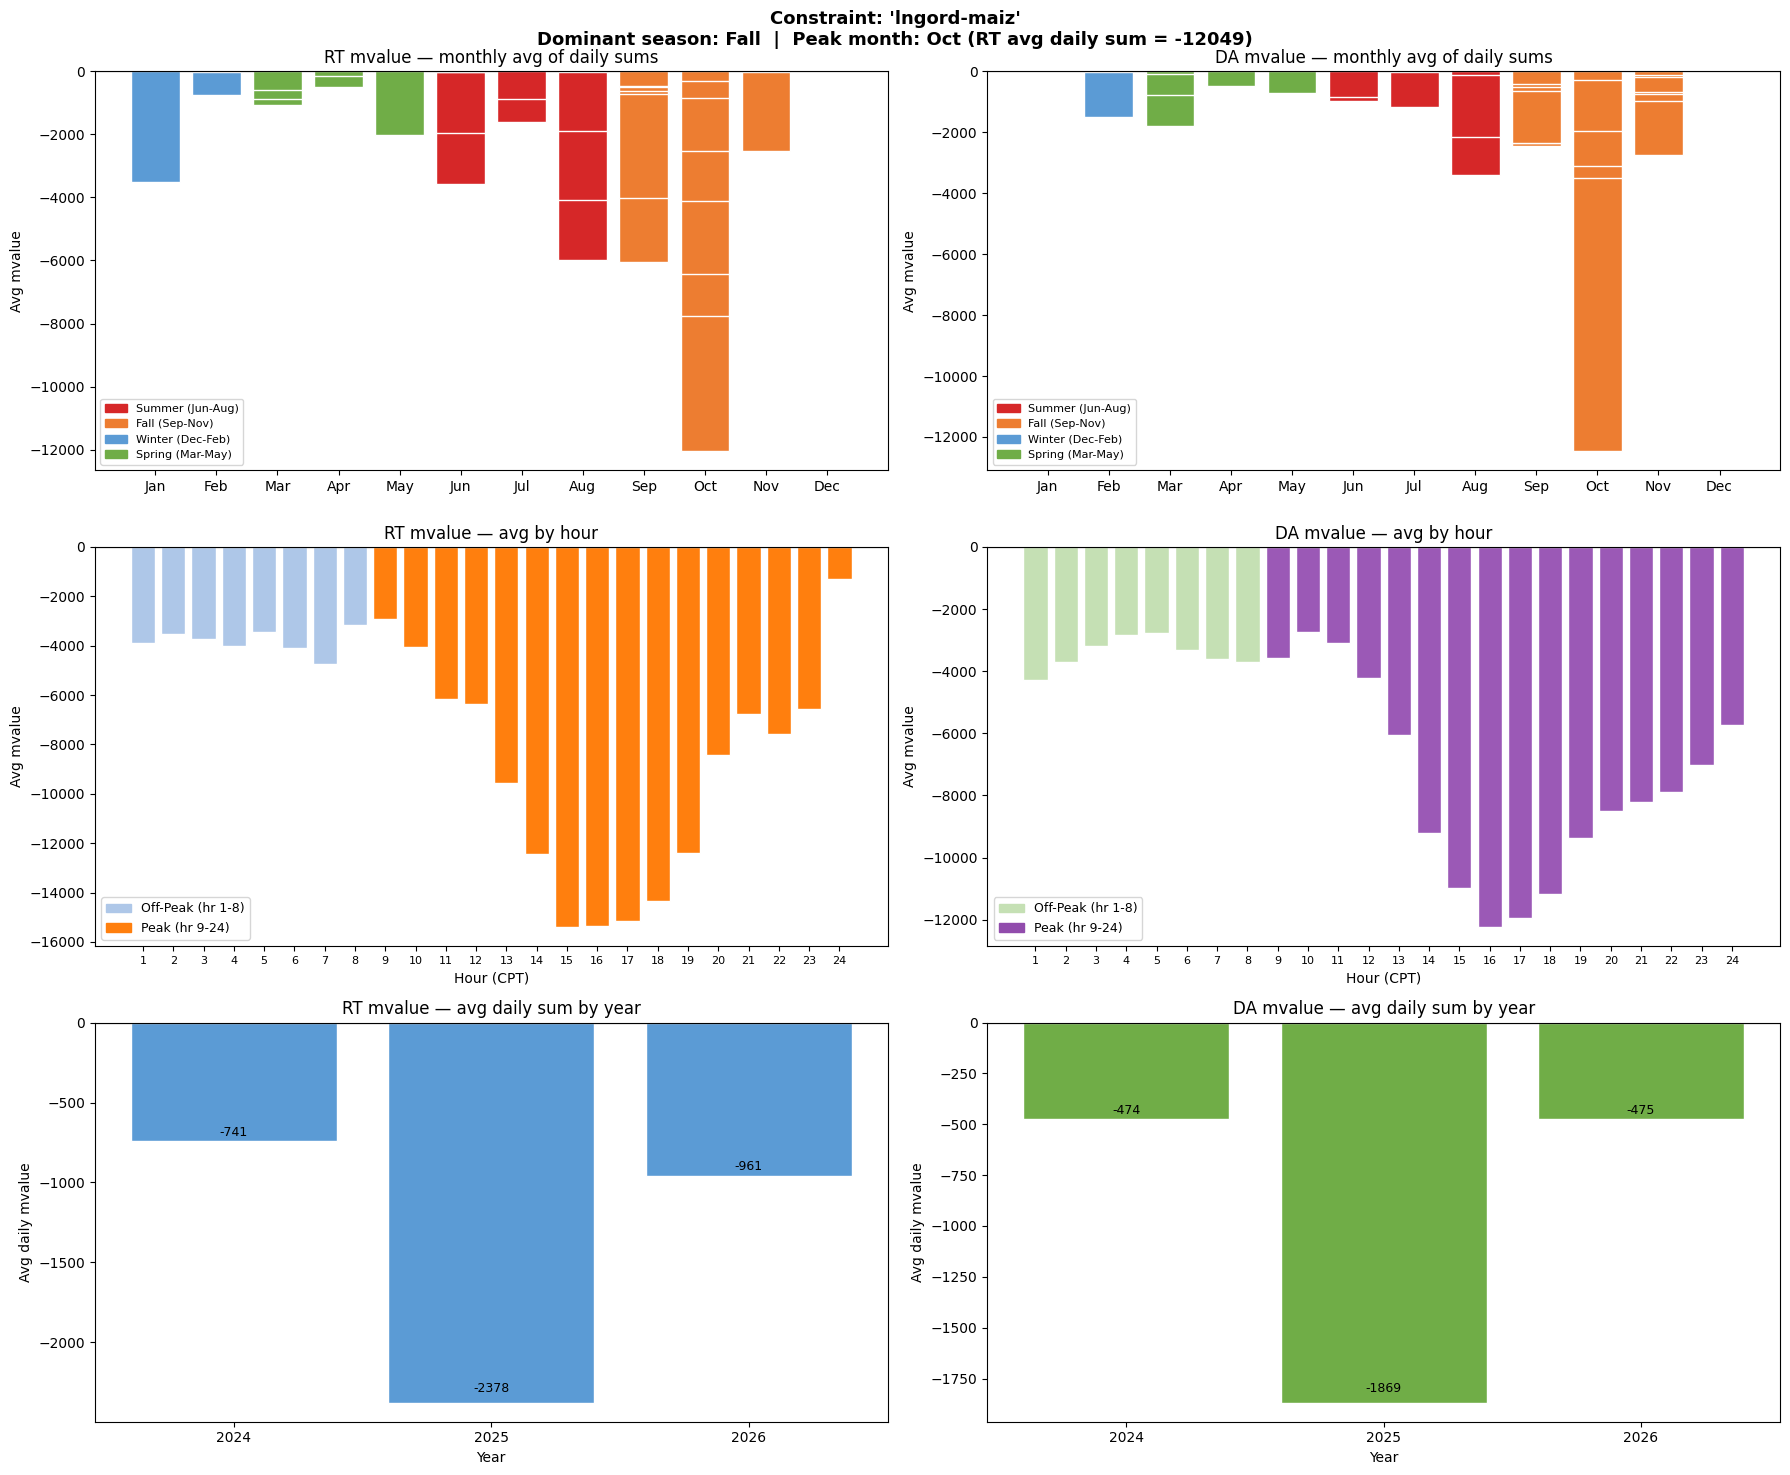

Dominant season : Fall
  Fall    :     132596  (sum abs RT daily mvalue)
  Summer  :      31138  (sum abs RT daily mvalue)
  Spring  :       7237  (sum abs RT daily mvalue)
  Winter  :       4298  (sum abs RT daily mvalue)

Peak month      : Oct  (daily RT sum = -12048.51)

RT  peak sum   (hr  9-24): -144715.78  |  off-peak (hr 1-8):  -30632.90
DA  peak sum   (hr  9-24): -121919.23  |  off-peak (hr 1-8):  -27436.01


TypeError: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid

In [126]:
for name in hourly_mvalue.monitored.unique():
    print(f"\nConstraint: {name}")

    zone_input = input("Enter reserve zone number (or press Enter to skip): ").strip()
    if zone_input == '':
        plot_constraint_seasonality(hourly_mvalue, name)
        table = get_constraints_node_price(hourly_mvalue, dfax,[name])
        get_metrics_for_nodes(table)
    else:
        zone = int(zone_input)
        analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 95)
        plot_constraint_seasonality(hourly_mvalue, name)
        table = get_constraints_node_price(hourly_mvalue, dfax,[name])
        get_metrics_for_nodes(table)
